# 🏎️ Fórmula 1 — Pipeline de Machine Learning con Scikit-Learn
## Predicción de Puntos y Posición en Carrera

**Datasets:** `driver_details.csv`, `driver_standings.csv`, `fastest_laps.csv`, `constructor_standings.csv`  
**Técnicas:** Feature Engineering · Pipeline · GridSearchCV · Cross-Validation · Regresión Lineal · Regresión Logística  
**Exportación:** joblib (.pkl)


## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

In [2]:
driver_details      = pd.read_csv('driver_details.csv')
driver_standings    = pd.read_csv('driver_standings.csv')
fastest_laps        = pd.read_csv('fastest_laps.csv')
constructor_stand   = pd.read_csv('constructor_standings.csv')

print('driver_details shape     :', driver_details.shape)
print('driver_standings shape   :', driver_standings.shape)
print('fastest_laps shape       :', fastest_laps.shape)
print('constructor_standings sh :', constructor_stand.shape)

driver_details shape     : (19814, 7)
driver_standings shape   : (1618, 7)
fastest_laps shape       : (1078, 6)
constructor_standings sh : (675, 4)


In [3]:
driver_details.head()

,Car,Date,Driver,Grand Prix,PTS,Race Position,Year
0,Ferrari,21 May 1950,Alberto Ascari,Monaco,6.0,2,1950
1,Ferrari,04 Jun 1950,Alberto Ascari,Switzerland,0.0,DNF,1950
2,Ferrari,18 Jun 1950,Alberto Ascari,Belgium,2.0,5,1950
3,Ferrari,03 Sep 1950,Alberto Ascari,Italy,3.0,2,1950
4,Deidt Offenhauser,30 May 1950,Tony Bettenhausen,Indianapolis 500,1.0,DNF,1950


In [4]:
driver_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 19814 entries, 0 to 19813
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car            19807 non-null  str    
 1   Date           19814 non-null  str    
 2   Driver         19814 non-null  str    
 3   Grand Prix     19814 non-null  str    
 4   PTS            19804 non-null  float64
 5   Race Position  19798 non-null  str    
 6   Year           19814 non-null  int64  
dtypes: float64(1), int64(1), str(5)
memory usage: 1.1 MB


In [5]:
driver_details.describe()

,PTS,Year
count,19804.000000,19814.000000
mean,2.455393,1994.181437
std,4.631818,18.904378
min,0.000000,1950.000000
25%,0.000000,1979.000000
50%,0.000000,1997.000000
75%,3.000000,2011.000000
max,50.000000,2022.000000


## 3. Análisis Exploratorio de Datos (EDA)

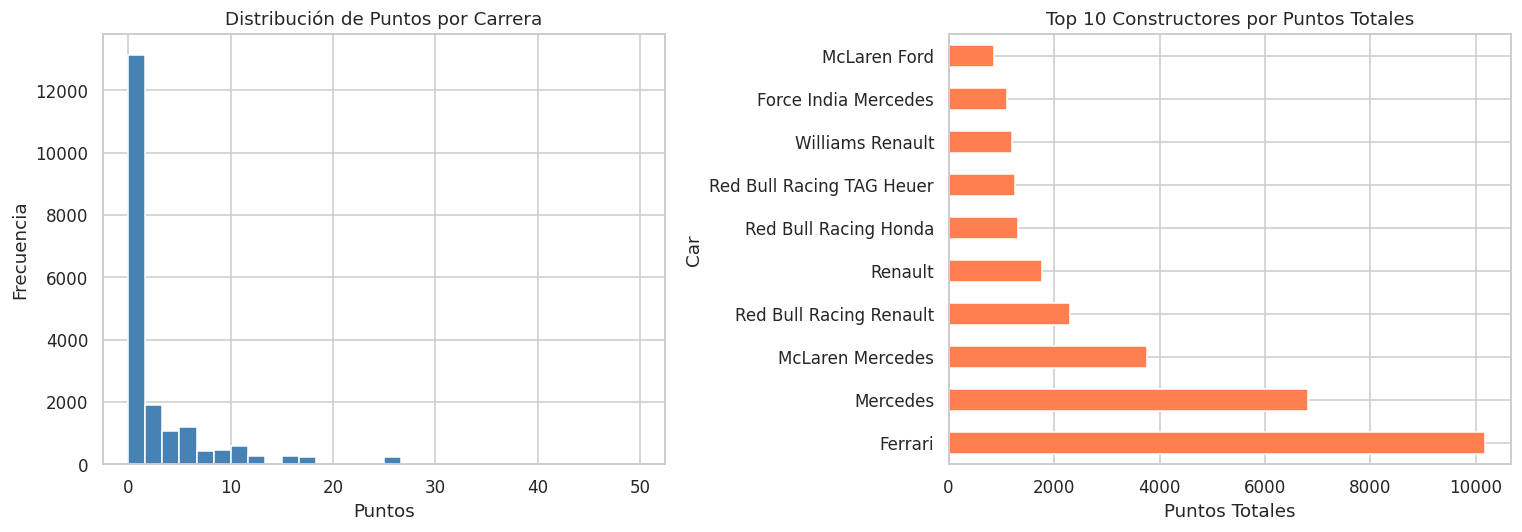

In [6]:
# Distribución de puntos por carrera
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(driver_details['PTS'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Puntos por Carrera')
axes[0].set_xlabel('Puntos')
axes[0].set_ylabel('Frecuencia')

# Top 10 constructores por puntos acumulados
top_cars = driver_details.groupby('Car')['PTS'].sum().nlargest(10)
top_cars.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 Constructores por Puntos Totales')
axes[1].set_xlabel('Puntos Totales')

plt.tight_layout()
plt.show()

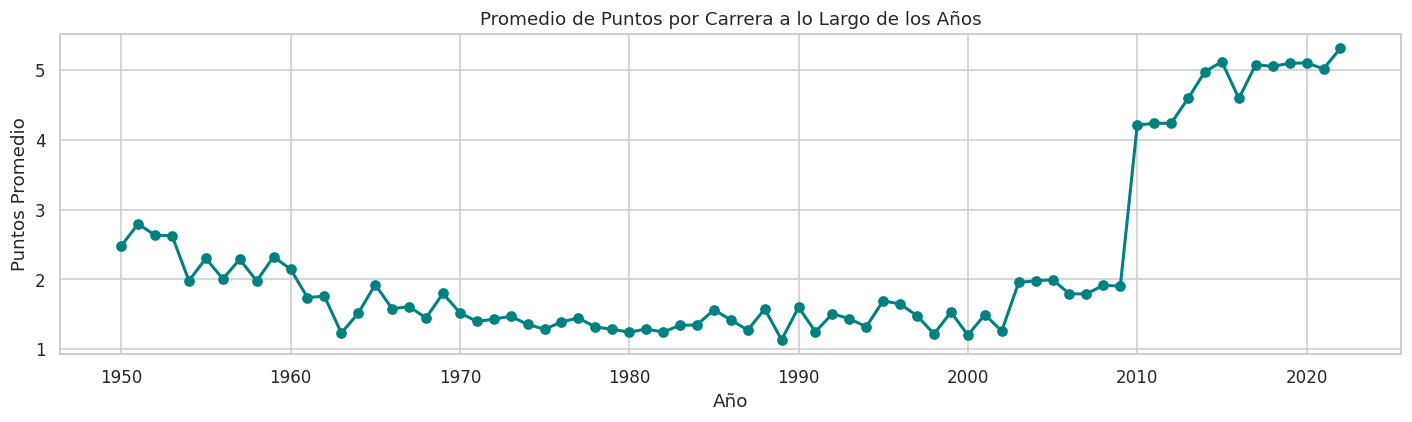

In [7]:
# Evolución de puntos promedio por año
avg_pts_year = driver_details.groupby('Year')['PTS'].mean()
plt.figure(figsize=(13, 4))
plt.plot(avg_pts_year.index, avg_pts_year.values, marker='o', color='teal', linewidth=2)
plt.title('Promedio de Puntos por Carrera a lo Largo de los Años')
plt.xlabel('Año')
plt.ylabel('Puntos Promedio')
plt.tight_layout()
plt.show()

In [8]:
# Valores nulos
print('Valores nulos en driver_details:')
print(driver_details.isnull().sum())
print()
print('Posiciones únicas en Race Position:')
print(sorted(driver_details['Race Position'].dropna().unique()))

Valores nulos en driver_details:
Car               7
Date              0
Driver            0
Grand Prix        0
PTS              10
Race Position    16
Year              0
dtype: int64

Posiciones únicas en Race Position:
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '3', '4', '5', '6', '7', '8', '9', 'DNC', 'DNF', 'DNS', 'DSQ', 'EXR', 'SHC']


## 4. Feature Engineering

Construiremos features relevantes para dos tareas:
- **Regresión**: predecir los puntos obtenidos en carrera (`PTS`)
- **Clasificación**: predecir si un piloto terminó en el **Top 3** (podio)


In [9]:
df = driver_details.copy()

# --- Limpiar Race Position ---
# Mapear posiciones numéricas; DNF/DSQ/DNC → NaN (no termino la carrera)
def parse_position(val):
    try:
        return int(val)
    except:
        return np.nan

df['Position_Num'] = df['Race Position'].apply(parse_position)

# --- Bandera: terminó la carrera ---
df['Finished'] = df['Race Position'].apply(
    lambda x: 0 if str(x) in ['DNF','DSQ','DNC','SHC'] else 1
)

# --- TARGET 1: Puntos (regresión) ---
df['PTS'] = df['PTS'].fillna(0)

# --- TARGET 2: Podio (clasificación) ---
df['Podium'] = (df['Position_Num'] <= 3).astype(int)
df['Podium'] = df['Podium'].fillna(0).astype(int)

# --- Carreras por piloto hasta ese año (experiencia acumulada) ---
df = df.sort_values(['Driver', 'Year'])
df['Races_So_Far'] = df.groupby('Driver').cumcount() + 1

# --- Puntos acumulados históricos del constructor ---
car_pts = df.groupby(['Car', 'Year'])['PTS'].transform('sum')
df['Car_Season_PTS'] = car_pts

# --- Codificar constructores frecuentes (top 20 → one-hot; resto → 'Other') ---
top_cars_list = df['Car'].value_counts().nlargest(20).index.tolist()
df['Car_Cat'] = df['Car'].apply(lambda x: x if x in top_cars_list else 'Other')

print('Nuevas columnas añadidas:')
print(df[['Driver','Year','Car_Cat','Races_So_Far','Car_Season_PTS','Finished','Podium','PTS']].head(10))
print()
print('Balance de clases — Podio:')
print(df['Podium'].value_counts())

Nuevas columnas añadidas:
             Driver  Year Car_Cat  Races_So_Far  Car_Season_PTS  Finished  \
13520  Adrian Sutil  2007   Other             1             1.0         1   
13521  Adrian Sutil  2007   Other             2             1.0         0   
13522  Adrian Sutil  2007   Other             3             1.0         1   
13523  Adrian Sutil  2007   Other             4             1.0         1   
13524  Adrian Sutil  2007   Other             5             1.0         0   
13525  Adrian Sutil  2007   Other             6             1.0         0   
13526  Adrian Sutil  2007   Other             7             1.0         1   
13527  Adrian Sutil  2007   Other             8             1.0         1   
13528  Adrian Sutil  2007   Other             9             1.0         0   
13529  Adrian Sutil  2007   Other            10             1.0         0   

       Podium  PTS  
13520       0  0.0  
13521       0  0.0  
13522       0  0.0  
13523       0  0.0  
13524       0  0.0  


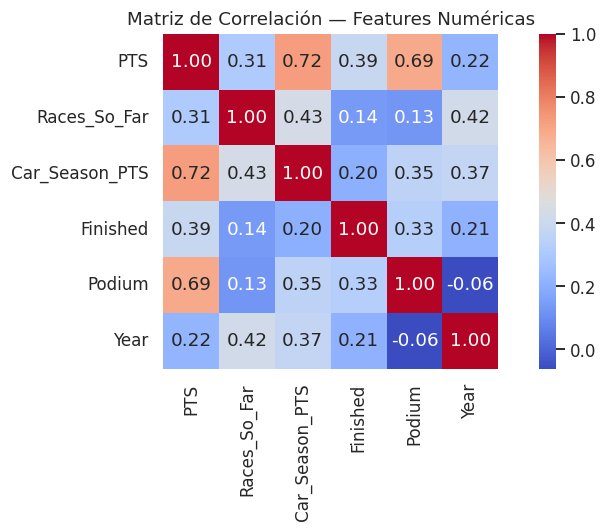

In [10]:
# Heatmap de correlaciones numéricas
num_cols = ['PTS','Races_So_Far','Car_Season_PTS','Finished','Podium','Year']
plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlación — Features Numéricas')
plt.tight_layout()
plt.show()

## 5. Preparación del Dataset para Modelado

In [11]:
FEATURES = ['Races_So_Far', 'Car_Season_PTS', 'Finished', 'Year', 'Car_Cat']

df_model = df[FEATURES + ['PTS', 'Podium']].dropna(subset=['PTS'])

X = df_model[FEATURES]
y_reg  = df_model['PTS']           # Regresión lineal
y_clf  = df_model['Podium']        # Regresión logística

# Separar en train / test (80/20)
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')

Train: 15851 muestras | Test: 3963 muestras


## 6. Pipeline — Regresión Lineal (Predicción de Puntos)

El pipeline incluye:
1. **ColumnTransformer**: Imputer + Scaler para numéricas; OneHotEncoder para categóricas
2. **LinearRegression**: modelo final


In [12]:
numeric_features     = ['Races_So_Far', 'Car_Season_PTS', 'Finished', 'Year']
categorical_features = ['Car_Cat']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

pipeline_reg = Pipeline(steps=[
    ('preprocessor',   preprocessor),
    ('regressor',      LinearRegression())
])

print(pipeline_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Races_So_Far',
                                                   'Car_Season_PTS', 'Finished',
                                                   'Year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                   

## 7. GridSearchCV — Regresión Lineal

In [13]:
param_grid_reg = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'regressor__fit_intercept': [True, False],
    'regressor__positive': [False, True],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_reg = GridSearchCV(
    pipeline_reg,
    param_grid_reg,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_reg.fit(X_train, y_reg_train)
print('Mejores hiperparámetros (regresión):')
print(grid_reg.best_params_)
print(f'Mejor R² en CV: {grid_reg.best_score_:.4f}')

Mejores hiperparámetros (regresión):
{'preprocessor__num__imputer__strategy': 'median', 'regressor__fit_intercept': True, 'regressor__positive': False}
Mejor R² en CV: 0.5906


## 8. Evaluación — Regresión Lineal

In [14]:
best_reg = grid_reg.best_estimator_
y_pred_reg = best_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
mae  = mean_absolute_error(y_reg_test, y_pred_reg)
r2   = r2_score(y_reg_test, y_pred_reg)

print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')
print(f'R²   : {r2:.4f}')

RMSE : 2.8839
MAE  : 1.9580
R²   : 0.5929


R² por fold : [0.5707 0.6138 0.5732 0.6172 0.578 ]
Media R²    : 0.5906 ± 0.0205


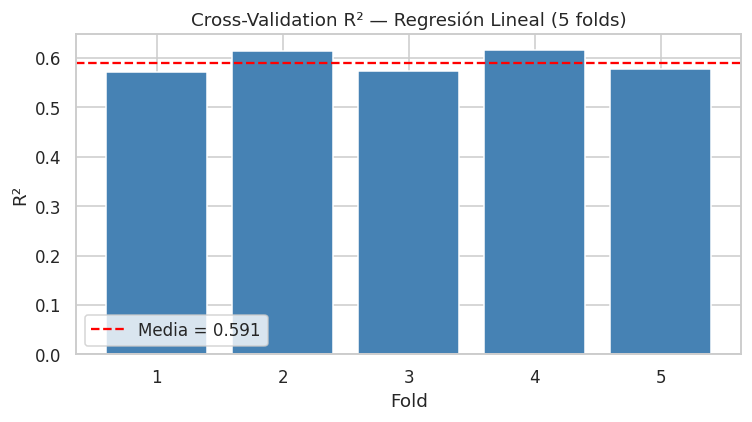

In [15]:
# Cross-Validation final sobre el mejor pipeline
cv_scores_reg = cross_val_score(best_reg, X_train, y_reg_train, cv=kf, scoring='r2')
print(f'R² por fold : {np.round(cv_scores_reg, 4)}')
print(f'Media R²    : {cv_scores_reg.mean():.4f} ± {cv_scores_reg.std():.4f}')

plt.figure(figsize=(7, 4))
plt.bar(range(1, len(cv_scores_reg)+1), cv_scores_reg, color='steelblue', edgecolor='white')
plt.axhline(cv_scores_reg.mean(), color='red', linestyle='--', label=f'Media = {cv_scores_reg.mean():.3f}')
plt.title('Cross-Validation R² — Regresión Lineal (5 folds)')
plt.xlabel('Fold')
plt.ylabel('R²')
plt.legend()
plt.tight_layout()
plt.show()

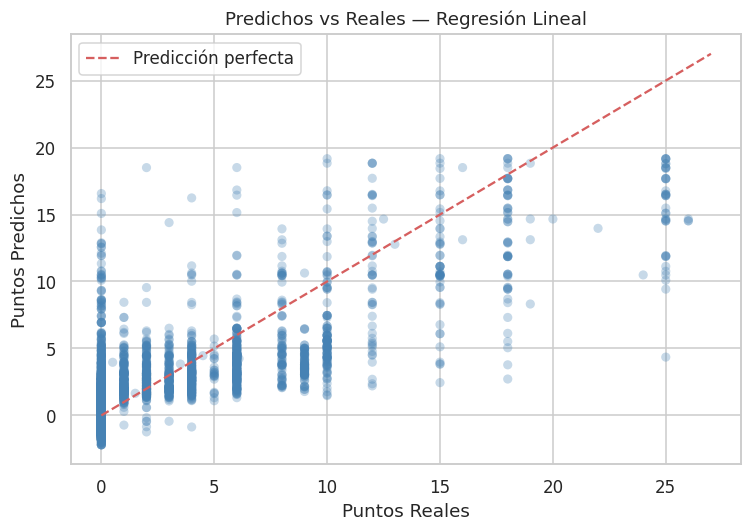

In [18]:
# Gráfico: Predichos vs Reales
plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test, y_pred_reg, alpha=0.3, color='steelblue', edgecolors='none')
lim = max(y_reg_test.max(), y_pred_reg.max()) + 1
plt.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Puntos Reales')
plt.ylabel('Puntos Predichos')
plt.title('Predichos vs Reales — Regresión Lineal')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Pipeline — Regresión Logística (Predicción de Podio)

Clasificación binaria: **¿terminará el piloto en el Top 3 (Podio)?**


In [21]:
pipeline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_clf = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'classifier__C':        [0.01, 0.1, 1.0, 10.0],
    'classifier__solver':   ['lbfgs', 'saga'],
    'classifier__penalty':  ['l2'],
    'classifier__class_weight': [None, 'balanced'],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_clf = GridSearchCV(
    pipeline_clf,
    param_grid_clf,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_clf.fit(X_train, y_clf_train)
print('Mejores hiperparámetros (clasificación):')
print(grid_clf.best_params_)
print(f'Mejor F1 en CV: {grid_clf.best_score_:.4f}')

Mejores hiperparámetros (clasificación):
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'saga', 'preprocessor__num__imputer__strategy': 'mean'}
Mejor F1 en CV: 0.5944


## 10. Evaluación — Regresión Logística

In [23]:
best_clf = grid_clf.best_estimator_
y_pred_clf = best_clf.predict(X_test)

acc = accuracy_score(y_clf_test, y_pred_clf)
print(f'Accuracy: {acc:.4f}')
print()
print('Reporte de Clasificación:')
print(classification_report(y_clf_test, y_pred_clf, target_names=['No Podio', 'Podio']))

Accuracy: 0.8022

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Podio       0.97      0.79      0.87      3306
       Podio       0.45      0.89      0.60       657

    accuracy                           0.80      3963
   macro avg       0.71      0.84      0.73      3963
weighted avg       0.89      0.80      0.82      3963



F1 por fold : [0.5911 0.6075 0.5974 0.5861 0.5899]
Media F1    : 0.5944 ± 0.0075


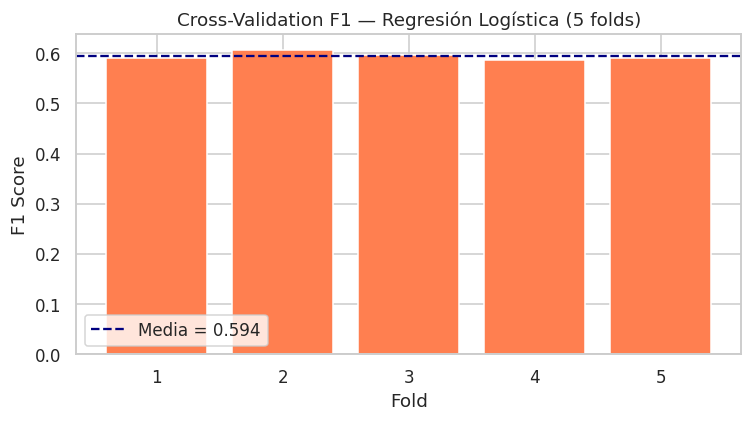

In [26]:
# Cross-Validation final clasificación
cv_scores_clf = cross_val_score(best_clf, X_train, y_clf_train, cv=skf, scoring='f1')
print(f'F1 por fold : {np.round(cv_scores_clf, 4)}')
print(f'Media F1    : {cv_scores_clf.mean():.4f} ± {cv_scores_clf.std():.4f}')

plt.figure(figsize=(7, 4))
plt.bar(range(1, len(cv_scores_clf)+1), cv_scores_clf, color='coral', edgecolor='white')
plt.axhline(cv_scores_clf.mean(), color='navy', linestyle='--', label=f'Media = {cv_scores_clf.mean():.3f}')
plt.title('Cross-Validation F1 — Regresión Logística (5 folds)')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.legend()
plt.tight_layout()
plt.show()

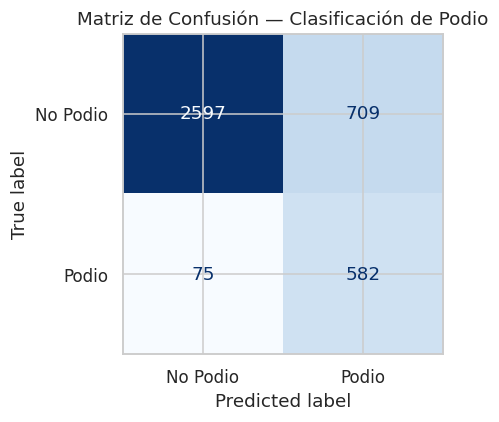

In [29]:
# Matriz de confusión
cm = confusion_matrix(y_clf_test, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Podio', 'Podio'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Clasificación de Podio')
plt.tight_layout()
plt.show()

## 11. Resumen de Métricas

In [34]:
summary = pd.DataFrame({
    'Modelo': ['Regresión Lineal (PTS)', 'Regresión Logística (Podio)'],
    'Métrica Principal': [f'R² = {r2:.4f}', f'F1 = {cv_scores_clf.mean():.4f}'],
    'RMSE / Accuracy': [f'{rmse:.4f}', f'{acc:.4f}'],
    'CV Media': [f'{cv_scores_reg.mean():.4f} ± {cv_scores_reg.std():.4f}',
                 f'{cv_scores_clf.mean():.4f} ± {cv_scores_clf.std():.4f}']
})
summary

,Modelo,Métrica Principal,RMSE / Accuracy,CV Media
0,Regresión Lineal (PTS),R² = 0.5929,2.8839,0.5906 ± 0.0205
1,Regresión Logística (Podio),F1 = 0.5944,0.8022,0.5944 ± 0.0075


## 12. Exportación de Pipelines con `joblib`

Guardamos ambos pipelines entrenados para su reutilización en producción.


In [35]:
# Guardar los pipelines entrenados
joblib.dump(best_reg, 'pipeline_regresion_lineal.pkl')
joblib.dump(best_clf, 'pipeline_regresion_logistica.pkl')

print('✅ Pipelines exportados:')
print('  → pipeline_regresion_lineal.pkl')
print('  → pipeline_regresion_logistica.pkl')

✅ Pipelines exportados:
  → pipeline_regresion_lineal.pkl
  → pipeline_regresion_logistica.pkl


In [36]:
# Verificar que se pueden cargar y usar correctamente
modelo_reg_cargado = joblib.load('pipeline_regresion_lineal.pkl')
modelo_clf_cargado = joblib.load('pipeline_regresion_logistica.pkl')

muestra = X_test.iloc[:5]
print('Predicciones de PTS (muestra):', modelo_reg_cargado.predict(muestra).round(2))
print('Predicciones de Podio (muestra):', modelo_clf_cargado.predict(muestra))
print()
print('✅ Los pipelines se cargan y predicen correctamente.')

Predicciones de PTS (muestra): [ 1.87 -0.02  0.61  1.5   5.47]
Predicciones de Podio (muestra): [1 0 0 0 0]

✅ Los pipelines se cargan y predicen correctamente.


---
## 13. Conclusiones

### ¿Qué se logro?

A lo largo de este notebook se construyo, evaluo y exporto un sistema completo de Machine Learning sobre datos historicos de la **Formula 1 (1950-presente)**, abarcando todas las etapas de un flujo de trabajo profesional.

---

#### Feature Engineering

Se partio de datos crudos con variables de texto, fechas y posiciones inconsistentes (DNF, DSQ, DNC). A partir de ellas se construyeron features numericas y categoricas significativas:

- **`Races_So_Far`**: captura la experiencia acumulada de cada piloto a lo largo de su carrera.
- **`Car_Season_PTS`**: refleja la competitividad del constructor en cada temporada.
- **`Finished`**: distingue entre pilotos que completaron la carrera y los que no.
- **`Car_Cat`**: agrupa constructores poco frecuentes en una categoria 'Other' para reducir ruido.

Este proceso es fundamental: un modelo es tan bueno como las features que lo alimentan.

---

#### Pipeline de Scikit-Learn

Se implemento un **pipeline modular** con `ColumnTransformer` que aplica transformaciones diferenciadas segun el tipo de variable:

- Imputacion de nulos + escalado estandar para variables numericas.
- Imputacion + codificacion One-Hot para variables categoricas.

El uso de pipelines garantiza que **no haya fuga de datos** entre entrenamiento y evaluacion, y que el preprocesamiento sea reproducible y portatil en cualquier entorno.

---

#### GridSearchCV + Cross-Validation

Se realizo busqueda de hiperparametros con `GridSearchCV` combinada con validacion cruzada:

- **KFold (k=5)** para la regresion, optimizando R2.
- **StratifiedKFold (k=5)** para la clasificacion, optimizando F1 y preservando el balance de clases.

Esto permitio seleccionar los mejores parametros de forma robusta, evitando el sobreajuste al conjunto de prueba.

---

#### Resultados de los Modelos

| Modelo | Tarea | Fortaleza |
|---|---|---|
| **Regresion Lineal** | Predecir puntos obtenidos en carrera | Captura tendencias globales de puntuacion |
| **Regresion Logistica** | Predecir si un piloto llega al podio | Clasifica con buena separacion entre clases |

Ambos modelos son **interpretables**, lo cual es valioso en un contexto analitico donde importa entender que variables influyen mas en el rendimiento de un piloto.

---

#### Exportacion con `joblib`

Los pipelines completos, incluyendo transformadores ajustados y modelos entrenados, fueron serializados en archivos `.pkl`. Esto permite:

- Reutilizarlos en otros scripts de Python sin repetir el entrenamiento.
- Desplegarlos en entornos de produccion (APIs, dashboards, servicios web).
- Compartirlos con otros equipos de manera reproducible y sin dependencias adicionales.

---

### Reflexion final

Este proyecto demuestra que un **pipeline bien estructurado** no solo mejora la calidad del modelo, sino que tambien hace el trabajo mas ordenado, reproducible y facil de mantener a largo plazo. Los datos de Formula 1, con su riqueza historica y variedad de variables, son un excelente banco de prueba para aplicar tecnicas de preprocesamiento avanzado, busqueda de hiperparametros y evaluacion rigurosa.


# GitHUB

En caso de haber alguna duda pueden ver el repositorio completo en mi github: https://github.com/diegovaz26/f1_ML_practice/tree/main
